# LangGraph Chatbot: Build Features Step by Step

This notebook builds a LangGraph chatbot one feature at a time. Each section adds one capability while keeping the previous graph easy to inspect and run.

Learning path:

1. Start with a basic Groq-powered chatbot graph using `Annotated` and `add_messages` for message state.
2. Add a chat loop with explicit conversation history and an exit condition.
3. Add an optional Gemini 2.0 Flash model path.
4. Stream graph execution so intermediate updates are visible.
5. Add tools and route tool calls through the graph.
6. Wrap the final graph in a small notebook-friendly helper function.


## Environment setup

Load credentials from the local `.env` file, require Groq for the main path, and detect whether Gemini is available. The imports include `Annotated` and `add_messages` because the first chatbot graph will use them to define how LangGraph should merge conversation messages.

In [1]:
import os
import sys
from typing import Annotated, TypedDict

from dotenv import load_dotenv
from IPython.display import Markdown, display
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages

load_dotenv()

assert os.getenv("GROQ_API_KEY"), "Add GROQ_API_KEY to your .env file."
HAS_GOOGLE_API_KEY = bool(os.getenv("GOOGLE_API_KEY"))

print(f"Python executable: {sys.executable}")
print(f"Gemini available: {HAS_GOOGLE_API_KEY}")


/Users/mlstudio/Claude-Code/ml-lab-new/tutorial-agentic-ai/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python executable: /Users/mlstudio/Claude-Code/ml-lab-new/tutorial-agentic-ai/.venv/bin/python3
Gemini available: True


## Step 1: Basic Groq chatbot graph

A chatbot graph needs to preserve a list of conversation messages. `Annotated` keeps the Python type as `list[BaseMessage]` while attaching LangGraph-specific merge behavior. The `add_messages` reducer tells LangGraph to append or merge new messages instead of replacing the whole list when a node returns an update.

In [2]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


groq_llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
)


def call_groq_chatbot(state: ChatState) -> ChatState:
    response = groq_llm.invoke(state["messages"])
    return {"messages": [response]}


Build the smallest useful chatbot graph: start, call the model once, then finish. The node returns only the new assistant message because `add_messages` handles merging it into the state.

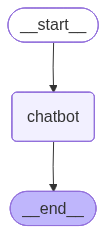

In [3]:
basic_builder = StateGraph(ChatState)
basic_builder.add_node("chatbot", call_groq_chatbot)
basic_builder.add_edge(START, "chatbot")
basic_builder.add_edge("chatbot", END)

basic_chatbot = basic_builder.compile()
basic_chatbot


Invoke the graph with a system instruction and one user message. The final state contains the original messages plus the assistant response.

In [4]:
basic_result = basic_chatbot.invoke(
    {
        "messages": [
            SystemMessage(content="You are a concise LangGraph tutor."),
            HumanMessage(content="In one sentence, why is Mars called the red planet?"),
        ]
    }
)

print(f"Messages in final state: {len(basic_result['messages'])}")
display(Markdown(basic_result["messages"][-1].content))


Messages in final state: 3


Mars is called the Red Planet due to its reddish appearance, which is caused by iron oxide, also known as rust, in the planet's soil and rocks.

## Step 2: Chat loop with an exit condition

The basic graph handles one turn. To make it feel like a chatbot, keep the conversation history in a Python list and pass that list into each new graph invocation. This is different from checkpoint memory: the loop owns the transcript explicitly, while `add_messages` still handles merging the assistant response during each graph run.

In [5]:
EXIT_COMMANDS = {"exit", "quit", "q", ":q", "bye"}


def should_exit(user_text: str) -> bool:
    return user_text.strip().lower() in EXIT_COMMANDS


def ask_with_history(messages: list[BaseMessage], user_text: str) -> list[BaseMessage]:
    result = basic_chatbot.invoke(
        {"messages": [*messages, HumanMessage(content=user_text)]}
    )
    return result["messages"]


Use a scripted conversation for a reproducible notebook run. The same exit condition works in an interactive loop.

In [6]:
conversation = [SystemMessage(content="You are a concise solar system tutor.")]
scripted_user_inputs = [
    "What is the largest planet in the solar system?",
    "quit",
]

for user_text in scripted_user_inputs:
    print(f"User: {user_text}")
    if should_exit(user_text):
        print("Assistant: Ending the chat loop.")
        break

    conversation = ask_with_history(conversation, user_text)
    print(f"Assistant: {conversation[-1].content}\n")

print(f"Messages kept in loop history: {len(conversation)}")


User: What is the largest planet in the solar system?


Assistant: The largest planet in our solar system is Jupiter. It has a diameter of approximately 142,984 kilometers (88,846 miles), making it more than 11 times the diameter of Earth.

User: quit
Assistant: Ending the chat loop.
Messages kept in loop history: 3


The live loop below is defined but not called automatically, so the notebook can execute from top to bottom without waiting for keyboard input. Run `chat_loop()` in a notebook cell when you want an interactive session.

In [7]:
def chat_loop() -> None:
    messages: list[BaseMessage] = [
        SystemMessage(content="You are a concise solar system tutor.")
    ]

    while True:
        user_text = input("You: ")
        if should_exit(user_text):
            print("Assistant: Ending the chat loop.")
            break

        messages = ask_with_history(messages, user_text)
        print(f"Assistant: {messages[-1].content}\n")


# Uncomment the next line in Jupyter to start a live chat session.
# chat_loop()
